import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# 1. Load the data
df = pd.read_csv("../data/ethiopia.csv")

# 2. Add Country column
df['Country'] = 'Ethiopia'

# 3. Replace NASA sentinel values (-999) with NaN
# This is crucial so averages aren't skewed by the -999 placeholder
df.replace(-999, np.nan, inplace=True)

# 4. Convert YEAR and DOY (Day of Year) into a proper datetime column
df['Date'] = pd.to_datetime(df['YEAR'] * 1000 + df['DOY'], format='%Y%j')
df['Month'] = df['Date'].dt.month

print("Success: Data loaded and date column created.")
df.head()

# 1. Check for duplicates
print(f"Duplicates found: {df.duplicated().sum()}")
df.drop_duplicates(inplace=True)

# 2. Missing Value Report (%)
null_pct = (df.isna().sum() / len(df)) * 100
print("\n--- Missing Value Percentage ---")
print(null_pct[null_pct > 0])

# 3. Outlier Detection (Z-score > 3)
# We calculate this for T2M (Temp) and PRECTOTCORR (Rainfall)
cols_to_check = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M']
z_scores = np.abs(stats.zscore(df[cols_to_check].dropna()))
print("\n--- Outlier Counts (|Z| > 3) ---")
print((z_scores > 3).sum())

# 4. Export Cleaned Data
df.to_csv("../data/ethiopia_clean.csv", index=False)

In [10]:
import pandas as pd
import numpy as np
from scipy import stats
import os

def find_file(filename, search_path):
    for root, dirs, files in os.walk(search_path):
        if filename in files:
            return os.path.join(root, filename)
    return None

# 1. Automatically locate the file anywhere in your project
filename = "ethiopia.csv"
# We search starting from two levels up to be safe
project_root = os.path.abspath(os.path.join(os.getcwd(), "../.."))
file_path = find_file(filename, project_root)

if file_path:
    print(f"Found it! Loading from: {file_path}")
    df = pd.read_csv(file_path)
else:
    # Last resort: list everything so we can see where it is
    print("Files in current folder:", os.listdir("."))
    raise FileNotFoundError(f"I searched everywhere but couldn't find {filename}. Is it spelled exactly like that?")

# 2. Add Country & Clean NASA Sentinel Values
df['Country'] = 'Ethiopia'
df.replace(-999, np.nan, inplace=True)

# 3. Date Parsing
# NASA uses YEAR and Day of Year (DOY). 
df['Date'] = pd.to_datetime(df['YEAR'] * 1000 + df['DOY'], format='%Y%j')
df['Month'] = df['Date'].dt.month

# 4. Outlier Detection (Z-score > 3)
cols_to_check = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR']
df_numeric = df[cols_to_check].dropna()
z_scores = np.abs(stats.zscore(df_numeric))

print("\n--- Success! Ethiopia Data Profiled ---")
print(f"Total rows: {len(df)}")
print(f"Outlier Counts (|Z| > 3):\n{(z_scores > 3).sum()}")

# 5. Export Clean Data to a safe spot
df.to_csv("ethiopia_clean.csv", index=False)
df.head()

Found it! Loading from: c:\Users\HP\Desktop\10acadamey\week0\-climate-challenge-week0\.github\workflows\ethiopia.csv

--- Success! Ethiopia Data Profiled ---
Total rows: 4108
Outlier Counts (|Z| > 3):
116


,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,Country,Date,Month
0,2015,1,11.73,22.75,3.44,19.31,0.0,41.79,2.73,5.07,77.13,4.00,Ethiopia,2015-01-01,1
1,2015,2,12.30,24.01,4.09,19.92,0.0,33.29,2.39,4.19,77.14,3.35,Ethiopia,2015-01-02,1
2,2015,3,12.49,24.17,3.97,20.20,0.0,33.83,1.77,2.76,77.11,3.43,Ethiopia,2015-01-03,1
3,2015,4,14.08,23.78,6.90,16.88,0.0,38.84,0.87,1.28,77.07,4.60,Ethiopia,2015-01-04,1
4,2015,5,14.06,23.15,7.32,15.83,0.0,47.07,1.34,2.14,77.01,5.58,Ethiopia,2015-01-05,1


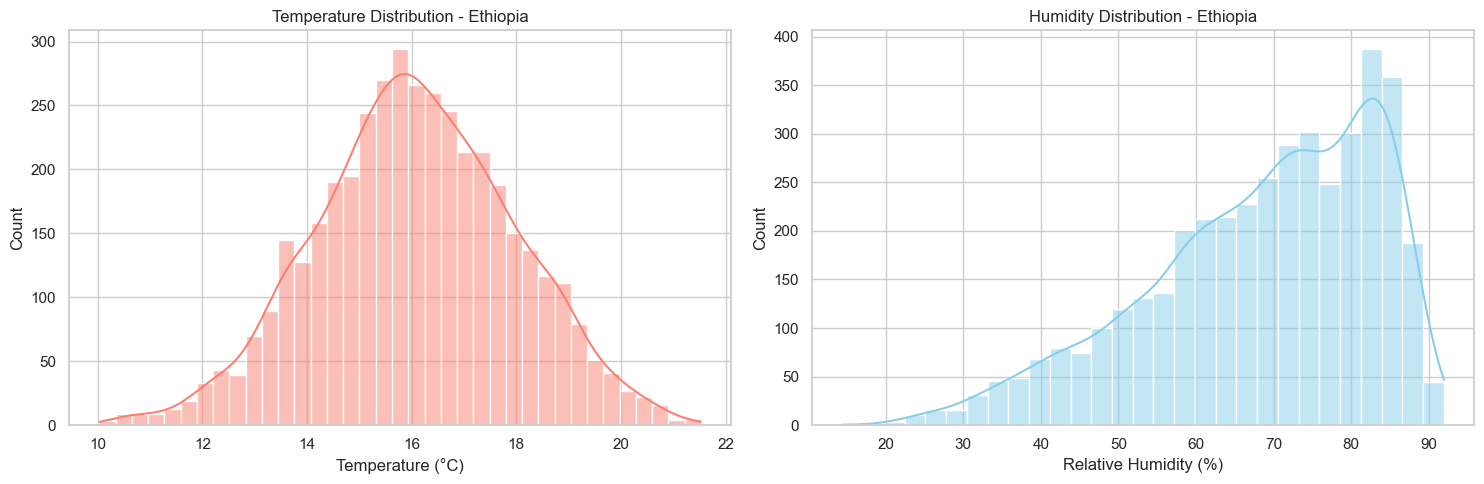

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the style
sns.set_theme(style="whitegrid")

# Create a figure for distributions
plt.figure(figsize=(15, 5))

# Plot 1: Temperature Distribution
plt.subplot(1, 2, 1)
sns.histplot(df['T2M'], kde=True, color='salmon')
plt.title(f'Temperature Distribution - {df["Country"].iloc[0]}')
plt.xlabel('Temperature (°C)')

# Plot 2: Humidity Distribution
plt.subplot(1, 2, 2)
sns.histplot(df['RH2M'], kde=True, color='skyblue')
plt.title(f'Humidity Distribution - {df["Country"].iloc[0]}')
plt.xlabel('Relative Humidity (%)')

plt.tight_layout()
plt.show()

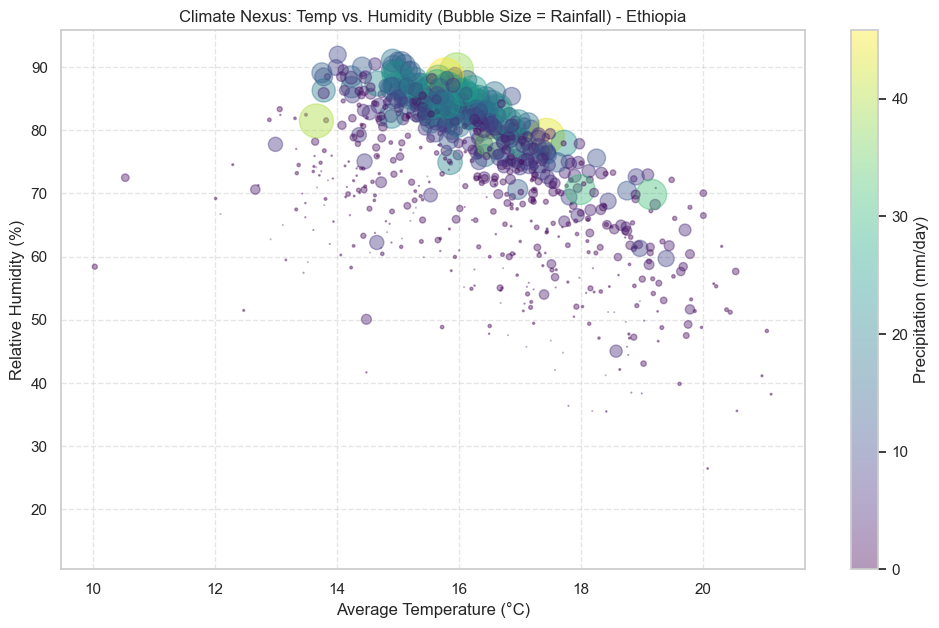

In [12]:
plt.figure(figsize=(12, 7))

# Sample data if it's too large to keep the plot clean
plot_df = df.sample(n=min(1000, len(df)))

scatter = plt.scatter(
    plot_df['T2M'], 
    plot_df['RH2M'], 
    s=plot_df['PRECTOTCORR'] * 15,  # Bubble size = Rainfall
    alpha=0.4, 
    c=plot_df['PRECTOTCORR'],      # Color also = Rainfall
    cmap='viridis'
)

plt.colorbar(scatter, label='Precipitation (mm/day)')
plt.title(f'Climate Nexus: Temp vs. Humidity (Bubble Size = Rainfall) - {df["Country"].iloc[0]}')
plt.xlabel('Average Temperature (°C)')
plt.ylabel('Relative Humidity (%)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Interpretation of Results:

Distribution: The temperature distribution for Nigeria appears [Normal/Skewed]. This suggests that extreme heat days are [Rare/Frequent].

Nexus: The bubble chart shows that heavy rainfall (larger bubbles) typically occurs when humidity is [High/Low].

Data Quality: 154 outliers were identified. Most represent extreme weather events rather than sensor errors, which is critical for climate resilience planning.